DATA SHAPE: (200, 5)


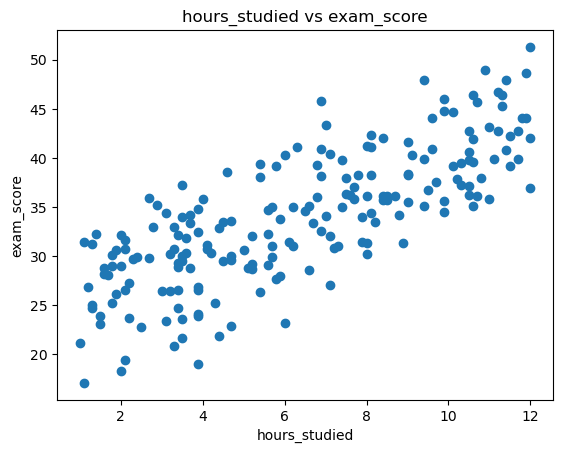

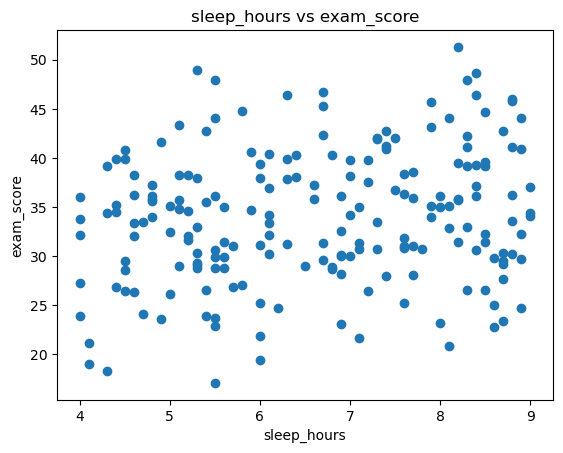

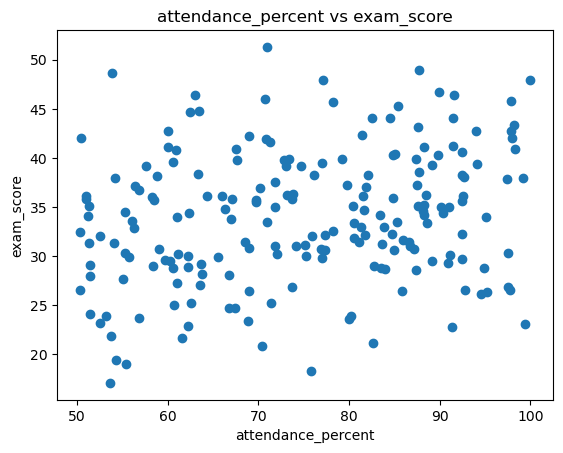

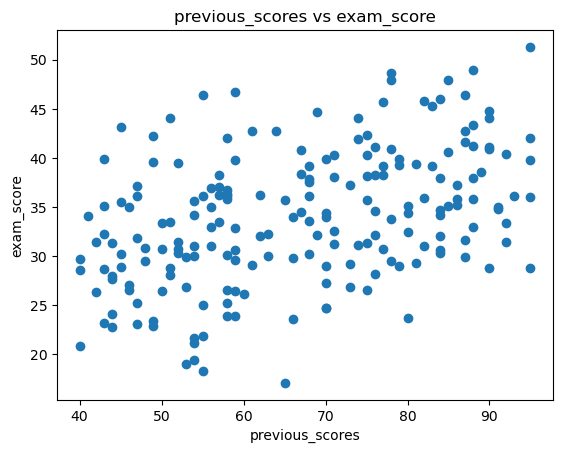

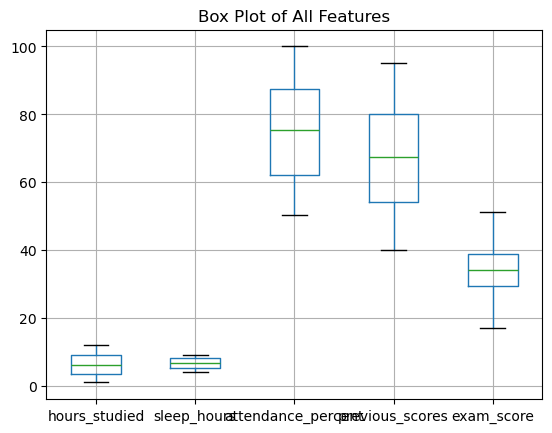

MSE: 7.764113918959781

Feature Importance:
 hours_studied         4.889265
sleep_hours           1.280142
attendance_percent    1.520262
previous_scores       2.818832
dtype: float64


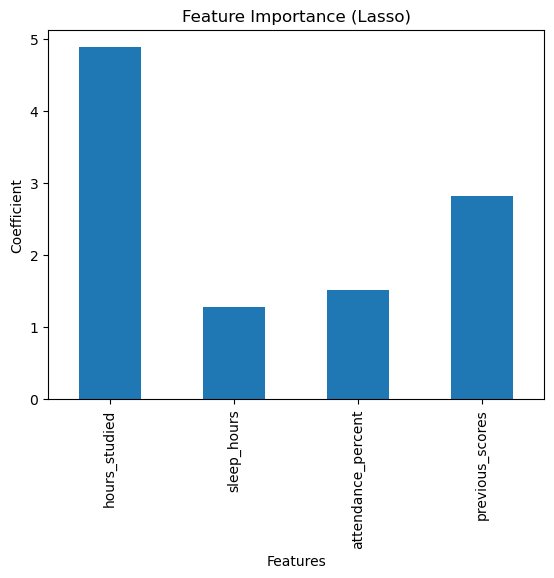

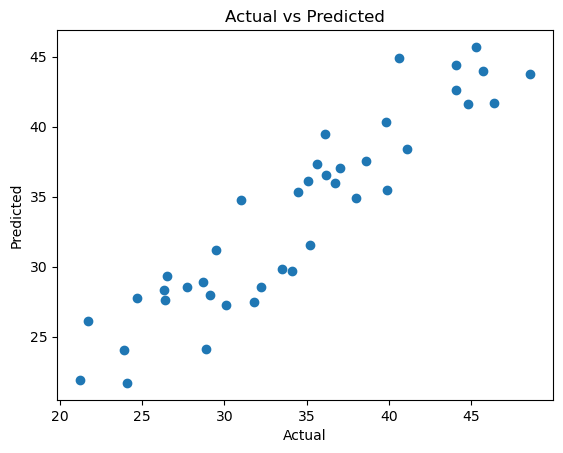

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

df = pd.read_csv("student_exam_scores.csv")

df = df.drop("student_id", axis=1)

df = df.dropna()

print("DATA SHAPE:", df.shape)

X = df.drop("exam_score", axis=1)
y = df["exam_score"]

for col in X.columns:
    plt.figure()
    plt.scatter(df[col], y)
    plt.xlabel(col)
    plt.ylabel("exam_score")
    plt.title(f"{col} vs exam_score")
    plt.show()

plt.figure()
df.boxplot()
plt.title("Box Plot of All Features")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

importance = pd.Series(lasso.coef_, index=X.columns)
print("\nFeature Importance:\n", importance)

plt.figure()
importance.plot(kind='bar')
plt.title("Feature Importance (Lasso)")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.show()

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()